        date       value  ewma_pandas  ewma_manual   ewma_span
0 2024-01-01  102.483571   102.483571   102.483571  102.483571
1 2024-01-02   99.813729   101.682618   101.682618  102.229300
2 2024-01-03  104.248544   102.452396   102.452396  102.421609
3 2024-01-04  109.130301   104.455767   104.455767  103.060532
4 2024-01-05  100.849435   103.373868   103.373868  102.849951
5 2024-01-06  101.354568   102.768078   102.768078  102.707534
6 2024-01-07  110.926367   105.215565   105.215565  103.490280
7 2024-01-08  107.372527   105.862653   105.862653  103.860018
8 2024-01-09  101.693032   104.611767   104.611767  103.653638
9 2024-01-10  107.258255   105.405713   105.405713  103.996935

EWMA with alpha=0.3
Original std: 15.53
EWMA std: 14.81


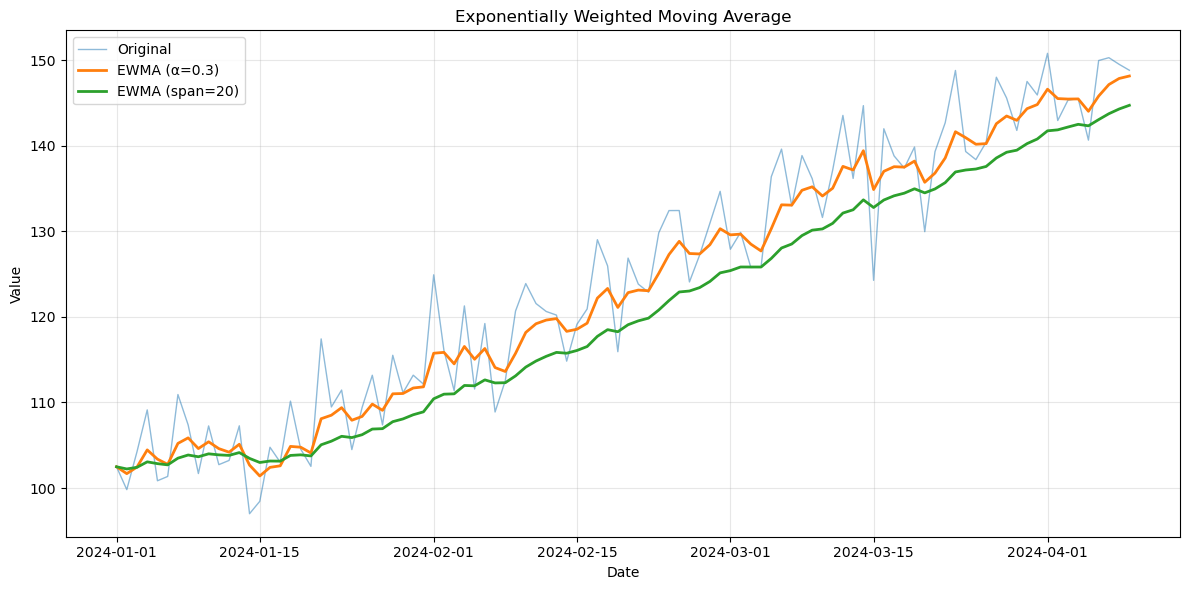

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate sample time series data
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=100, freq='D')
# Create a noisy time series with an underlying trend
values = np.linspace(100, 150, 100) + np.random.normal(0, 5, 100)
df = pd.DataFrame({'date': dates, 'value': values})

# Method 1: Using pandas ewm() - recommended approach
alpha = 0.3  # smoothing factor (0 < alpha <= 1)
df['ewma_pandas'] = df['value'].ewm(alpha=alpha, adjust=False).mean()

# Method 2: Manual implementation
def ewma_manual(data, alpha):
    """
    Calculate EWMA manually
    EWMA(t) = alpha * X(t) + (1 - alpha) * EWMA(t-1)
    """
    ewma = np.zeros(len(data))
    ewma[0] = data[0]  # Initialize with first value
    
    for t in range(1, len(data)):
        ewma[t] = alpha * data[t] + (1 - alpha) * ewma[t-1]
    
    return ewma

df['ewma_manual'] = ewma_manual(df['value'].values, alpha)

# Method 3: Using span parameter (common in finance)
# span = 2/alpha - 1, so span = 20 corresponds to alpha ≈ 0.095
df['ewma_span'] = df['value'].ewm(span=20, adjust=False).mean()

# Display results
print(df.head(10))
print(f"\nEWMA with alpha={alpha}")
print(f"Original std: {df['value'].std():.2f}")
print(f"EWMA std: {df['ewma_pandas'].std():.2f}")

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['value'], label='Original', alpha=0.5, linewidth=1)
plt.plot(df['date'], df['ewma_pandas'], label=f'EWMA (α={alpha})', linewidth=2)
plt.plot(df['date'], df['ewma_span'], label='EWMA (span=20)', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Exponentially Weighted Moving Average')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CUSUM Analysis Results
Target mean: 51.74
Actual shift introduced at index: 168
Shift magnitude: 8
Threshold: 57.18

Upward shift detected at indices: [11 12 13 14 15]
Downward shift detected at indices: [33 34 35 36 37]


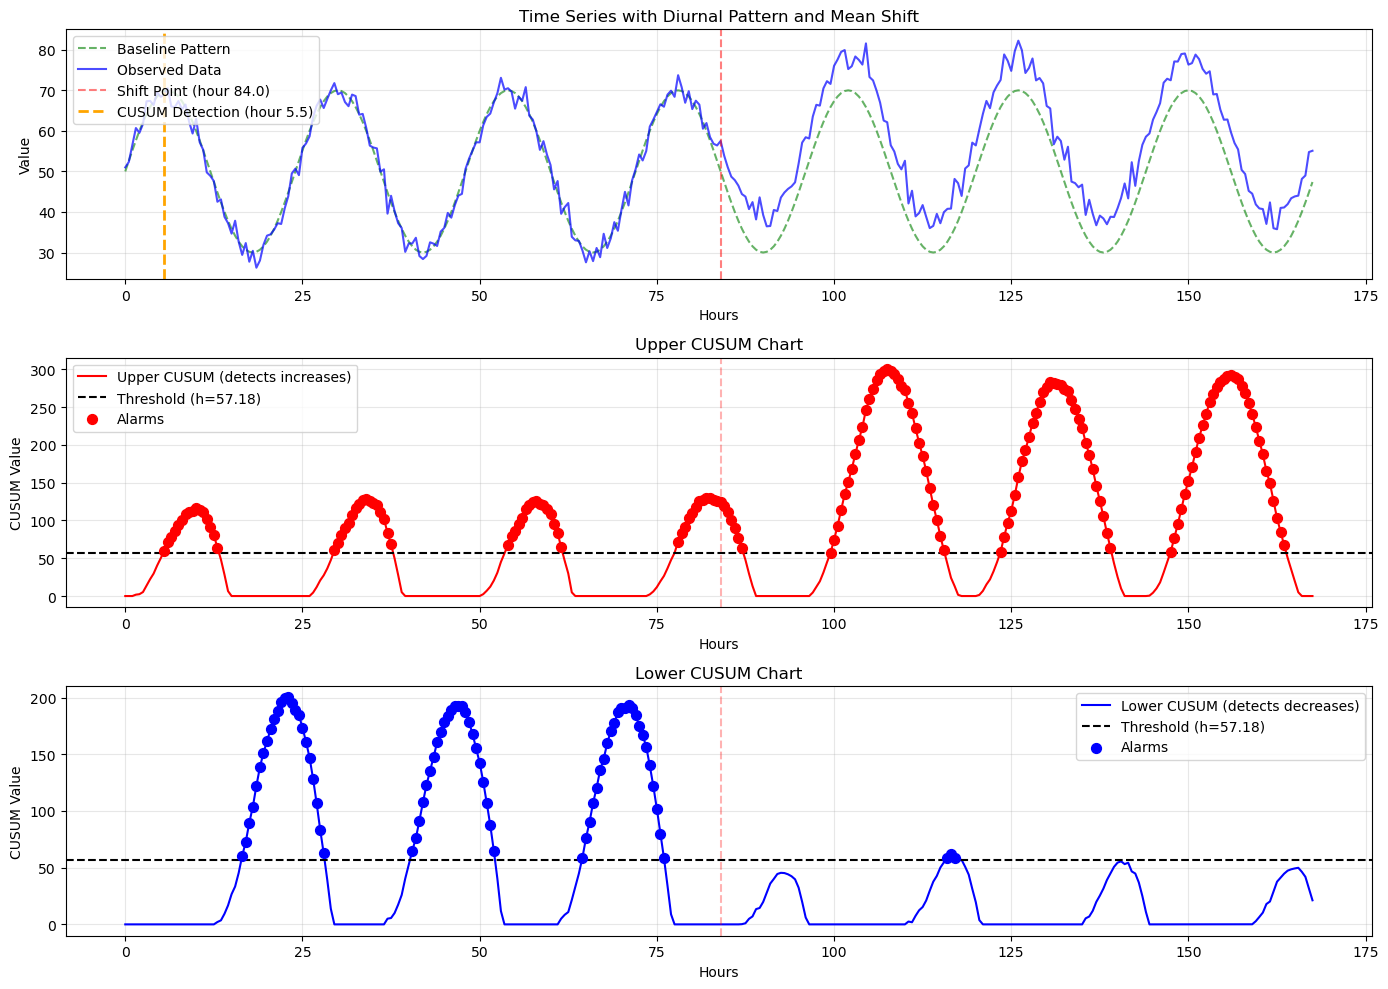


CUSUM on Residuals (Pattern-Adjusted)
Upward shift in residuals detected at index: 168
Detection delay: 0 periods


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate time series with diurnal (daily) sinusoidal pattern
np.random.seed(42)
hours = np.arange(0, 24*7, 0.5)  # One week of data at 30-minute intervals
n_points = len(hours)

# Create baseline diurnal pattern (24-hour cycle)
baseline = 50 + 20 * np.sin(2 * np.pi * hours / 24)  # Amplitude of 20, mean of 50

# Add some random noise
noise = np.random.normal(0, 2, n_points)

# Create a shift/anomaly in the middle of the time series
shift_start = n_points // 2
shift_magnitude = 8
data = baseline + noise
data[shift_start:] += shift_magnitude  # Introduce a mean shift

# Create DataFrame
df = pd.DataFrame({
    'hours': hours,
    'value': data,
    'baseline': baseline
})

# CUSUM Implementation
def cusum(data, target=None, std_dev=None, k=0.5, h=4):
    """
    CUSUM (Cumulative Sum Control Chart)
    
    Parameters:
    -----------
    data : array-like
        Input time series data
    target : float
        Target mean (if None, uses mean of data)
    std_dev : float
        Standard deviation (if None, calculated from data)
    k : float
        Allowance/slack parameter (typically 0.5 to 1.0 std devs)
    h : float
        Decision interval/threshold (typically 4 to 5 std devs)
    
    Returns:
    --------
    cusum_high : array
        Upper CUSUM values
    cusum_low : array
        Lower CUSUM values
    alarms_high : array
        Indices where upper threshold exceeded
    alarms_low : array
        Indices where lower threshold exceeded
    """
    if target is None:
        # Use first half of data as reference to detect shift in second half
        target = np.mean(data[:len(data)//2])
    
    if std_dev is None:
        std_dev = np.std(data[:len(data)//2])
    
    n = len(data)
    cusum_high = np.zeros(n)
    cusum_low = np.zeros(n)
    
    # Calculate CUSUM
    for i in range(1, n):
        # Upper CUSUM (detects upward shifts)
        cusum_high[i] = max(0, cusum_high[i-1] + (data[i] - target) - k * std_dev)
        
        # Lower CUSUM (detects downward shifts)
        cusum_low[i] = max(0, cusum_low[i-1] - (data[i] - target) - k * std_dev)
    
    # Detect alarms
    threshold = h * std_dev
    alarms_high = np.where(cusum_high > threshold)[0]
    alarms_low = np.where(cusum_low > threshold)[0]
    
    return cusum_high, cusum_low, alarms_high, alarms_low, threshold

# Apply CUSUM
cusum_high, cusum_low, alarms_high, alarms_low, threshold = cusum(
    df['value'].values, 
    k=0.5,  # Sensitivity parameter
    h=4     # Threshold parameter
)

df['cusum_high'] = cusum_high
df['cusum_low'] = cusum_low

# Print detection results
print("CUSUM Analysis Results")
print("=" * 50)
print(f"Target mean: {np.mean(df['value'][:len(df)//2]):.2f}")
print(f"Actual shift introduced at index: {shift_start}")
print(f"Shift magnitude: {shift_magnitude}")
print(f"Threshold: {threshold:.2f}")
print(f"\nUpward shift detected at indices: {alarms_high[:5] if len(alarms_high) > 0 else 'None'}")
print(f"Downward shift detected at indices: {alarms_low[:5] if len(alarms_low) > 0 else 'None'}")

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Original data with baseline and shift
axes[0].plot(df['hours'], df['baseline'], 'g--', label='Baseline Pattern', alpha=0.6)
axes[0].plot(df['hours'], df['value'], 'b-', label='Observed Data', alpha=0.7)
axes[0].axvline(x=hours[shift_start], color='r', linestyle='--', 
                label=f'Shift Point (hour {hours[shift_start]:.1f})', alpha=0.5)
if len(alarms_high) > 0:
    axes[0].axvline(x=hours[alarms_high[0]], color='orange', linestyle='--', 
                    label=f'CUSUM Detection (hour {hours[alarms_high[0]]:.1f})', linewidth=2)
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Value')
axes[0].set_title('Time Series with Diurnal Pattern and Mean Shift')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Upper CUSUM
axes[1].plot(df['hours'], df['cusum_high'], 'r-', label='Upper CUSUM (detects increases)')
axes[1].axhline(y=threshold, color='k', linestyle='--', label=f'Threshold (h={threshold:.2f})')
axes[1].axvline(x=hours[shift_start], color='r', linestyle='--', alpha=0.3)
if len(alarms_high) > 0:
    axes[1].scatter(df['hours'].iloc[alarms_high], df['cusum_high'].iloc[alarms_high], 
                   color='red', s=50, zorder=5, label='Alarms')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('CUSUM Value')
axes[1].set_title('Upper CUSUM Chart')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Lower CUSUM
axes[2].plot(df['hours'], df['cusum_low'], 'b-', label='Lower CUSUM (detects decreases)')
axes[2].axhline(y=threshold, color='k', linestyle='--', label=f'Threshold (h={threshold:.2f})')
axes[2].axvline(x=hours[shift_start], color='r', linestyle='--', alpha=0.3)
if len(alarms_low) > 0:
    axes[2].scatter(df['hours'].iloc[alarms_low], df['cusum_low'].iloc[alarms_low], 
                   color='blue', s=50, zorder=5, label='Alarms')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('CUSUM Value')
axes[2].set_title('Lower CUSUM Chart')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Alternative: CUSUM with residuals (removes diurnal pattern first)
print("\n" + "="*50)
print("CUSUM on Residuals (Pattern-Adjusted)")
print("="*50)

# Calculate residuals by removing the sinusoidal pattern
df['residuals'] = df['value'] - df['baseline']

cusum_high_res, cusum_low_res, alarms_high_res, alarms_low_res, threshold_res = cusum(
    df['residuals'].values,
    k=0.5,
    h=4
)

print(f"Upward shift in residuals detected at index: {alarms_high_res[0] if len(alarms_high_res) > 0 else 'None'}")
print(f"Detection delay: {alarms_high_res[0] - shift_start if len(alarms_high_res) > 0 else 'N/A'} periods")


Control Chart Comparison
True shift points: 150 (small shift +3), 350 (large shift +8)

EWMA Detection:
  First violation at: 153
  Total violations: 302

CUSUM Detection:
  First upward violation at: 153
  Total upward violations: 347

Hybrid EWMA-CUSUM Detection:
  First upward violation at: 12
  Total upward violations: 345


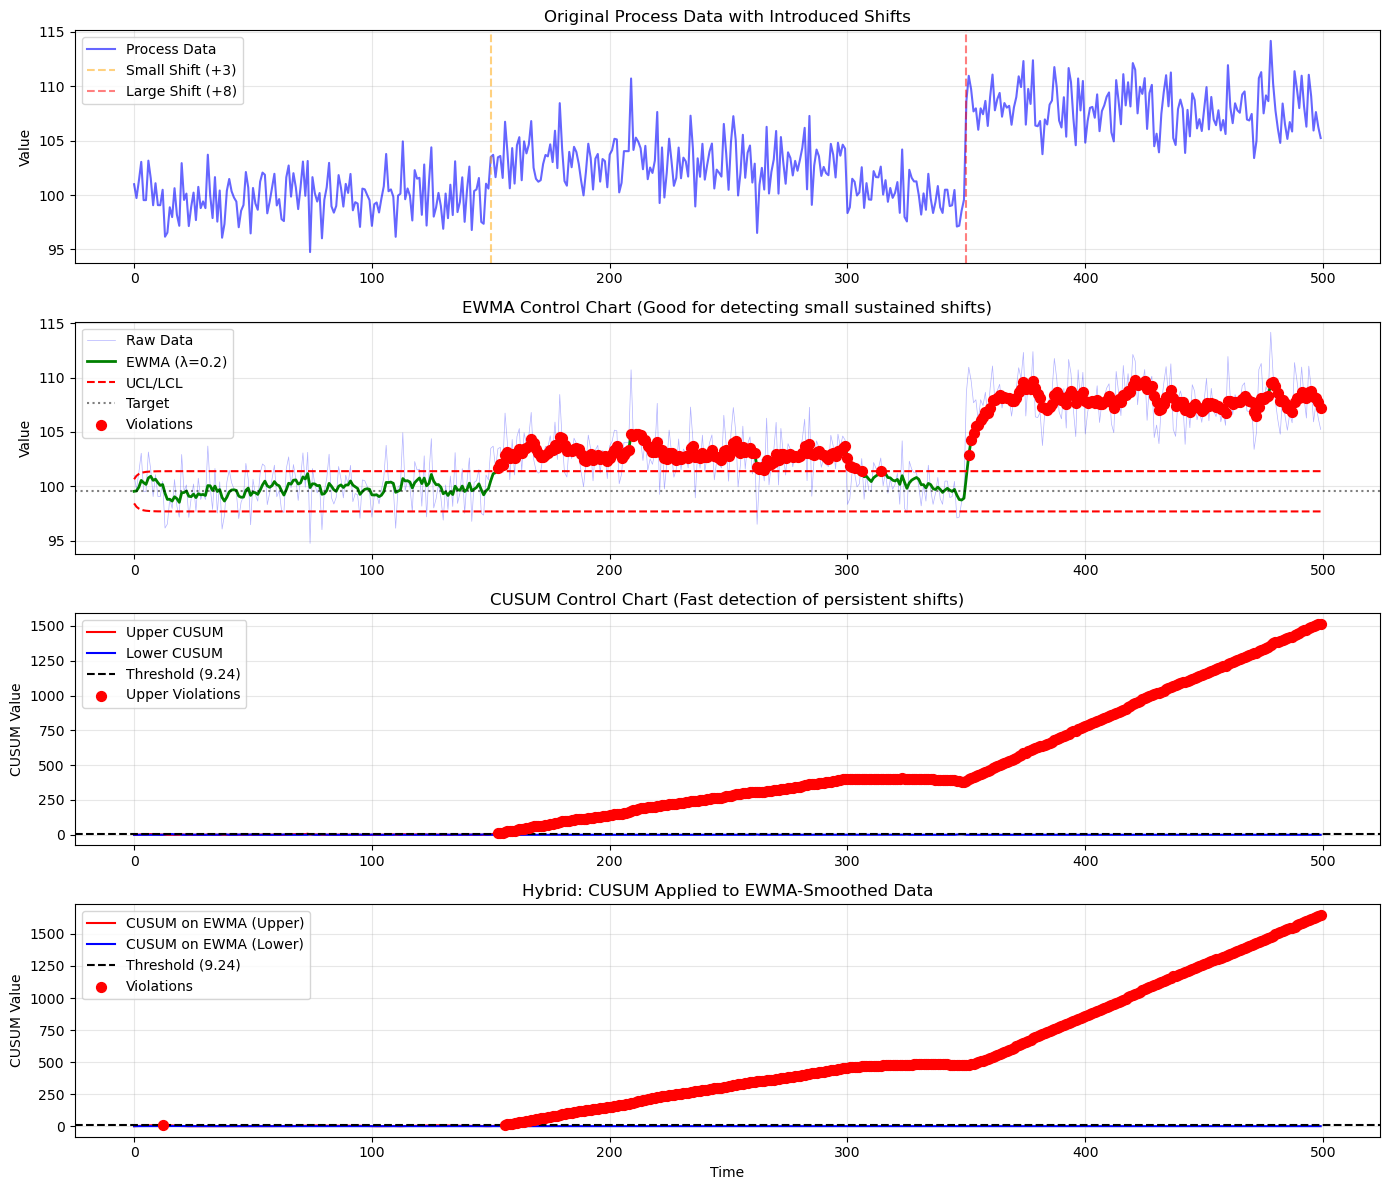


Detection Performance Summary

Small Shift (+3) Detection Delay:
  EWMA      : 3
  CUSUM     : 3
  Hybrid    : 6

Large Shift (+8) Detection Delay:
  EWMA      : 1
  CUSUM     : 0
  Hybrid    : 0

When to Use Each Method:

EWMA:
  ✓ Best for detecting small, gradual shifts (0.5-2σ)
  ✓ Weighted average provides smooth tracking
  ✓ Good for trending processes
  ✓ Single chart to monitor
  
CUSUM:
  ✓ Best for detecting small, sustained shifts quickly
  ✓ More sensitive to persistent changes
  ✓ Provides directional information (upper/lower)
  ✓ Requires two charts (upper and lower)
  
Hybrid (EWMA + CUSUM):
  ✓ Combines smoothing with shift detection
  ✓ Can reduce false alarms in noisy data
  ✓ More complex to implement and interpret
  ✓ Consider when data is very noisy but shifts are important

Side-by-Side (Both Independently):
  ✓ Use both for comprehensive monitoring
  ✓ EWMA for overall trends, CUSUM for shift detection
  ✓ Provides complementary information
  ✓ Common in critica

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate sample data with different types of shifts
np.random.seed(42)
n_points = 500
time = np.arange(n_points)

# Create baseline with small random variation
baseline = 100 + np.random.normal(0, 2, n_points)

# Introduce different types of shifts
data = baseline.copy()
# Small sustained shift at point 150
data[150:300] += 3
# Larger abrupt shift at point 350
data[350:] += 8

df = pd.DataFrame({'time': time, 'value': data})

# ============================================================================
# EWMA Control Chart
# ============================================================================
def ewma_control_chart(data, lambda_param=0.2, L=3, target=None, sigma=None):
    """
    EWMA Control Chart
    
    Parameters:
    -----------
    data : array-like
        Process data
    lambda_param : float
        Smoothing parameter (0 < λ ≤ 1), typically 0.05-0.25
    L : float
        Width of control limits (typically 2.6-3.0)
    target : float
        Target mean (if None, uses mean of first portion)
    sigma : float
        Process standard deviation (if None, calculated from data)
    """
    if target is None:
        target = np.mean(data[:50])  # Use first 50 points as reference
    
    if sigma is None:
        sigma = np.std(data[:50])
    
    n = len(data)
    z = np.zeros(n)
    z[0] = target
    
    # Calculate EWMA values
    for i in range(1, n):
        z[i] = lambda_param * data[i] + (1 - lambda_param) * z[i-1]
    
    # Calculate control limits
    ucl = np.zeros(n)
    lcl = np.zeros(n)
    
    for i in range(n):
        factor = np.sqrt(lambda_param / (2 - lambda_param) * (1 - (1 - lambda_param)**(2*(i+1))))
        ucl[i] = target + L * sigma * factor
        lcl[i] = target - L * sigma * factor
    
    # Detect out-of-control points
    violations = np.where((z > ucl) | (z < lcl))[0]
    
    return z, ucl, lcl, violations

# ============================================================================
# CUSUM Control Chart
# ============================================================================
def cusum_control_chart(data, k=0.5, h=5, target=None, sigma=None):
    """
    CUSUM Control Chart (same as before)
    """
    if target is None:
        target = np.mean(data[:50])
    
    if sigma is None:
        sigma = np.std(data[:50])
    
    n = len(data)
    cusum_high = np.zeros(n)
    cusum_low = np.zeros(n)
    
    for i in range(1, n):
        cusum_high[i] = max(0, cusum_high[i-1] + (data[i] - target) - k * sigma)
        cusum_low[i] = max(0, cusum_low[i-1] - (data[i] - target) - k * sigma)
    
    threshold = h * sigma
    violations_high = np.where(cusum_high > threshold)[0]
    violations_low = np.where(cusum_low > threshold)[0]
    
    return cusum_high, cusum_low, threshold, violations_high, violations_low

# ============================================================================
# Combined EWMA-CUSUM (Hybrid Approach)
# ============================================================================
def hybrid_ewma_cusum(data, lambda_param=0.2, k=0.5, h=5, target=None, sigma=None):
    """
    Hybrid approach: Apply CUSUM to EWMA-smoothed data
    
    This can be useful for:
    1. Detecting shifts in already-smoothed data
    2. Getting benefits of both techniques
    """
    if target is None:
        target = np.mean(data[:50])
    
    if sigma is None:
        sigma = np.std(data[:50])
    
    # First, apply EWMA smoothing
    n = len(data)
    ewma = np.zeros(n)
    ewma[0] = data[0]
    
    for i in range(1, n):
        ewma[i] = lambda_param * data[i] + (1 - lambda_param) * ewma[i-1]
    
    # Then apply CUSUM to the EWMA values
    cusum_high = np.zeros(n)
    cusum_low = np.zeros(n)
    
    # Use smaller k for EWMA-smoothed data since it's already smoothed
    k_adjusted = k * 0.5
    
    for i in range(1, n):
        cusum_high[i] = max(0, cusum_high[i-1] + (ewma[i] - target) - k_adjusted * sigma)
        cusum_low[i] = max(0, cusum_low[i-1] - (ewma[i] - target) - k_adjusted * sigma)
    
    threshold = h * sigma
    violations_high = np.where(cusum_high > threshold)[0]
    violations_low = np.where(cusum_low > threshold)[0]
    
    return ewma, cusum_high, cusum_low, threshold, violations_high, violations_low

# ============================================================================
# Apply all methods
# ============================================================================

# EWMA
ewma_values, ewma_ucl, ewma_lcl, ewma_violations = ewma_control_chart(
    df['value'].values, lambda_param=0.2, L=3
)

# CUSUM
cusum_high, cusum_low, cusum_threshold, cusum_viol_high, cusum_viol_low = cusum_control_chart(
    df['value'].values, k=0.5, h=5
)

# Hybrid EWMA-CUSUM
hybrid_ewma, hybrid_cusum_high, hybrid_cusum_low, hybrid_threshold, hybrid_viol_high, hybrid_viol_low = hybrid_ewma_cusum(
    df['value'].values, lambda_param=0.2, k=0.5, h=5
)

# ============================================================================
# Analysis and Comparison
# ============================================================================
print("Control Chart Comparison")
print("=" * 70)
print(f"True shift points: 150 (small shift +3), 350 (large shift +8)")
print()
print(f"EWMA Detection:")
print(f"  First violation at: {ewma_violations[0] if len(ewma_violations) > 0 else 'None'}")
print(f"  Total violations: {len(ewma_violations)}")
print()
print(f"CUSUM Detection:")
print(f"  First upward violation at: {cusum_viol_high[0] if len(cusum_viol_high) > 0 else 'None'}")
print(f"  Total upward violations: {len(cusum_viol_high)}")
print()
print(f"Hybrid EWMA-CUSUM Detection:")
print(f"  First upward violation at: {hybrid_viol_high[0] if len(hybrid_viol_high) > 0 else 'None'}")
print(f"  Total upward violations: {len(hybrid_viol_high)}")

# ============================================================================
# Visualization
# ============================================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Plot 1: Original data
axes[0].plot(df['time'], df['value'], 'b-', alpha=0.6, label='Process Data')
axes[0].axvline(x=150, color='orange', linestyle='--', alpha=0.5, label='Small Shift (+3)')
axes[0].axvline(x=350, color='red', linestyle='--', alpha=0.5, label='Large Shift (+8)')
axes[0].set_ylabel('Value')
axes[0].set_title('Original Process Data with Introduced Shifts')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: EWMA Control Chart
axes[1].plot(df['time'], df['value'], 'b-', alpha=0.3, linewidth=0.5, label='Raw Data')
axes[1].plot(df['time'], ewma_values, 'g-', linewidth=2, label='EWMA (λ=0.2)')
axes[1].plot(df['time'], ewma_ucl, 'r--', label='UCL/LCL')
axes[1].plot(df['time'], ewma_lcl, 'r--')
axes[1].axhline(y=np.mean(df['value'][:50]), color='k', linestyle=':', alpha=0.5, label='Target')
if len(ewma_violations) > 0:
    axes[1].scatter(df['time'].iloc[ewma_violations], ewma_values[ewma_violations], 
                   color='red', s=50, zorder=5, label='Violations')
axes[1].set_ylabel('Value')
axes[1].set_title('EWMA Control Chart (Good for detecting small sustained shifts)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: CUSUM Control Chart
axes[2].plot(df['time'], cusum_high, 'r-', label='Upper CUSUM')
axes[2].plot(df['time'], cusum_low, 'b-', label='Lower CUSUM')
axes[2].axhline(y=cusum_threshold, color='k', linestyle='--', label=f'Threshold ({cusum_threshold:.2f})')
if len(cusum_viol_high) > 0:
    axes[2].scatter(df['time'].iloc[cusum_viol_high], cusum_high[cusum_viol_high], 
                   color='red', s=50, zorder=5, label='Upper Violations')
axes[2].set_ylabel('CUSUM Value')
axes[2].set_title('CUSUM Control Chart (Fast detection of persistent shifts)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Hybrid EWMA-CUSUM
axes[3].plot(df['time'], hybrid_cusum_high, 'r-', label='CUSUM on EWMA (Upper)')
axes[3].plot(df['time'], hybrid_cusum_low, 'b-', label='CUSUM on EWMA (Lower)')
axes[3].axhline(y=hybrid_threshold, color='k', linestyle='--', label=f'Threshold ({hybrid_threshold:.2f})')
if len(hybrid_viol_high) > 0:
    axes[3].scatter(df['time'].iloc[hybrid_viol_high], hybrid_cusum_high[hybrid_viol_high], 
                   color='red', s=50, zorder=5, label='Violations')
axes[3].set_xlabel('Time')
axes[3].set_ylabel('CUSUM Value')
axes[3].set_title('Hybrid: CUSUM Applied to EWMA-Smoothed Data')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# Performance Comparison
# ============================================================================
print("\n" + "=" * 70)
print("Detection Performance Summary")
print("=" * 70)

def calculate_detection_delay(violations, true_shift_point):
    if len(violations) == 0:
        return None
    first_detection = violations[violations >= true_shift_point]
    if len(first_detection) == 0:
        return None
    return first_detection[0] - true_shift_point

# Small shift detection
small_shift_delays = {
    'EWMA': calculate_detection_delay(ewma_violations, 150),
    'CUSUM': calculate_detection_delay(cusum_viol_high, 150),
    'Hybrid': calculate_detection_delay(hybrid_viol_high, 150)
}

# Large shift detection
large_shift_delays = {
    'EWMA': calculate_detection_delay(ewma_violations, 350),
    'CUSUM': calculate_detection_delay(cusum_viol_high, 350),
    'Hybrid': calculate_detection_delay(hybrid_viol_high, 350)
}

print("\nSmall Shift (+3) Detection Delay:")
for method, delay in small_shift_delays.items():
    print(f"  {method:10s}: {delay if delay is not None else 'Not detected'}")

print("\nLarge Shift (+8) Detection Delay:")
for method, delay in large_shift_delays.items():
    print(f"  {method:10s}: {delay if delay is not None else 'Not detected'}")

print("\n" + "=" * 70)
print("When to Use Each Method:")
print("=" * 70)
print("""
EWMA:
  ✓ Best for detecting small, gradual shifts (0.5-2σ)
  ✓ Weighted average provides smooth tracking
  ✓ Good for trending processes
  ✓ Single chart to monitor
  
CUSUM:
  ✓ Best for detecting small, sustained shifts quickly
  ✓ More sensitive to persistent changes
  ✓ Provides directional information (upper/lower)
  ✓ Requires two charts (upper and lower)
  
Hybrid (EWMA + CUSUM):
  ✓ Combines smoothing with shift detection
  ✓ Can reduce false alarms in noisy data
  ✓ More complex to implement and interpret
  ✓ Consider when data is very noisy but shifts are important

Side-by-Side (Both Independently):
  ✓ Use both for comprehensive monitoring
  ✓ EWMA for overall trends, CUSUM for shift detection
  ✓ Provides complementary information
  ✓ Common in critical process monitoring
""")